# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
cleaned_aviation_data = pd.read_csv("data/AviationData_clean.csv")

In [3]:
cleaned_aviation_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17879 entries, 0 to 17878
Data columns (total 29 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Event.Id                               17879 non-null  object 
 1   Investigation.Type                     17879 non-null  object 
 2   Accident.Number                        17879 non-null  object 
 3   Event.Date                             17879 non-null  object 
 4   Location                               17875 non-null  object 
 5   Country                                17878 non-null  object 
 6   Injury.Severity                        17162 non-null  object 
 7   Aircraft.damage                        17879 non-null  object 
 8   Aircraft.Category                      17879 non-null  object 
 9   Registration.Number                    17715 non-null  object 
 10  Make                                   17879 non-null  object 
 11  Mo

In [4]:
cleaned_aviation_data.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,...,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Publication.Date,Total.number.of.passengers,Total.fatal.or.serious.injuries,Likelihood.of.serious.or.fatal.injury,Is.aircraft.destroyed,Make.model,Weather.Condition.missingness
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,Incident,Minor,Airplane,9VSQQ,...,0,588,VMC,04-12-2014,588,0,0.000000,False,Boeing/747,False
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,Fatal(1),Destroyed,Airplane,N9600W,...,0,1,IMC,02-05-2011,3,2,0.666667,True,Piper/pa-28-140,False
2,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,Fatal(1),Missing/Unknown,Airplane,N927BA,...,0,4,VMC,17-10-2016,5,1,0.200000,False,De Havilland/dhc-6,False
3,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,Incident,Minor,Airplane,N898AA,...,0,100,VMC,11-06-2018,100,0,0.000000,False,Boeing/727-200,False
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,Non-Fatal,Substantial,Airplane,N1882D,...,0,1,VMC,05-05-2011,1,0,0.000000,False,Beech/c35,False


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [5]:
passenger_threshold = 20 # At most this, then it would be smaller airplane, and exceed this, then it would be larger airplane.
cleaned_aviation_data["Is.smaller.airplane"] = cleaned_aviation_data["Total.number.of.passengers"] <= passenger_threshold


In [6]:
print(cleaned_aviation_data["Is.smaller.airplane"].info())
print()
print(cleaned_aviation_data["Is.smaller.airplane"].value_counts())
print()
cleaned_aviation_data[["Is.smaller.airplane", "Total.number.of.passengers"]].head()

<class 'pandas.core.series.Series'>
RangeIndex: 17879 entries, 0 to 17878
Series name: Is.smaller.airplane
Non-Null Count  Dtype
--------------  -----
17879 non-null  bool 
dtypes: bool(1)
memory usage: 17.6 KB
None

Is.smaller.airplane
True     17005
False      874
Name: count, dtype: int64



,Is.smaller.airplane,Total.number.of.passengers
0,False,588
1,True,3
2,True,5
3,False,100
4,True,1


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [7]:
result1 = cleaned_aviation_data.groupby(["Is.smaller.airplane", "Make"])["Likelihood.of.serious.or.fatal.injury"].agg(["mean", "count"])
# ---------------------------------------------------
# Although I did not see that assignment instructions say do this, I felt it was needed to provided a proper analysis.
# I am choosing a sample size for each group to be about 30 as this tends to be the standard.
result1 = result1[result1["count"] >= 30]
#-----------------------------------------------------
larger_airplane_15_lowest = result1.loc[False, "mean"].sort_values()[:15]
smaller_airplane_15_lowest = result1.loc[True, "mean"].sort_values()[:15]
result1

mean  count
Is.smaller.airplane Make                                           
False               Airbus                          0.086174    118
                    Boeing                          0.056687    547
                    Bombardier Inc                  0.028690     43
                    Embraer                         0.065274     78
                    Mcdonnell Douglas               0.007827     53
True                Aero Commander                  0.384815     90
                    Aeronca                         0.216667    200
                    Air Tractor                     0.339806    206
                    Air Tractor Inc                 0.335616    219
                    Airbus                          0.028706    125
                    American Champion Aircraft      0.269231     52
                    Aviat                           0.214286     70
                    Aviat Aircraft Inc              0.164474     76
                    Ayres                           0.195513     52
                    Beech                           0.358921   1430
                    Bellanca                        0.214992    219
                    Boeing                          0.053418    714
                    Cessna                          0.256325   7140
                    Champion                        0.260021    158
                    Cirrus                          0.437105    137
                    Cirrus Design Corp              0.407803    220
                    De Havilland                    0.343222     64
                    Dehavilland                     0.229188     94
                    Diamond Aircraft Ind Inc        0.222973     74
                    Embraer                         0.294509     74
                    Ercoupe                         0.320513     52
                    Grumman                         0.339299    146
                    Grumman Acft Eng Cor-Schweizer  0.206897     58
                    Luscombe                        0.274232    141
                    Maule                           0.161705    215
                    Mcdonnell Douglas               0.051299     55
                    Mooney                          0.356728    363
                    North American                  0.348270    106
                    Piper                           0.286737   3987
                    Raytheon Aircraft Company       0.359409     62
                    Rockwell International          0.219828     58
                    Socata                          0.455333     75
                    Stinson                         0.216408    129
                    Taylorcraft                     0.293907     93

In [8]:
print(larger_airplane_15_lowest)
print()
print(smaller_airplane_15_lowest)

Make
Mcdonnell Douglas    0.007827
Bombardier Inc       0.028690
Boeing               0.056687
Embraer              0.065274
Airbus               0.086174
Name: mean, dtype: float64

Make
Airbus                            0.028706
Mcdonnell Douglas                 0.051299
Boeing                            0.053418
Maule                             0.161705
Aviat Aircraft Inc                0.164474
Ayres                             0.195513
Grumman Acft Eng Cor-Schweizer    0.206897
Aviat                             0.214286
Bellanca                          0.214992
Stinson                           0.216408
Aeronca                           0.216667
Rockwell International            0.219828
Diamond Aircraft Ind Inc          0.222973
Dehavilland                       0.229188
Cessna                            0.256325
Name: mean, dtype: float64


In [9]:
print(larger_airplane_15_lowest.describe())
print()
print(smaller_airplane_15_lowest.describe())

count    5.000000
mean     0.048930
std      0.030877
min      0.007827
25%      0.028690
50%      0.056687
75%      0.065274
max      0.086174
Name: mean, dtype: float64

count    15.000000
mean      0.176845
std       0.072514
min       0.028706
25%       0.163090
50%       0.214286
75%       0.218247
max       0.256325
Name: mean, dtype: float64


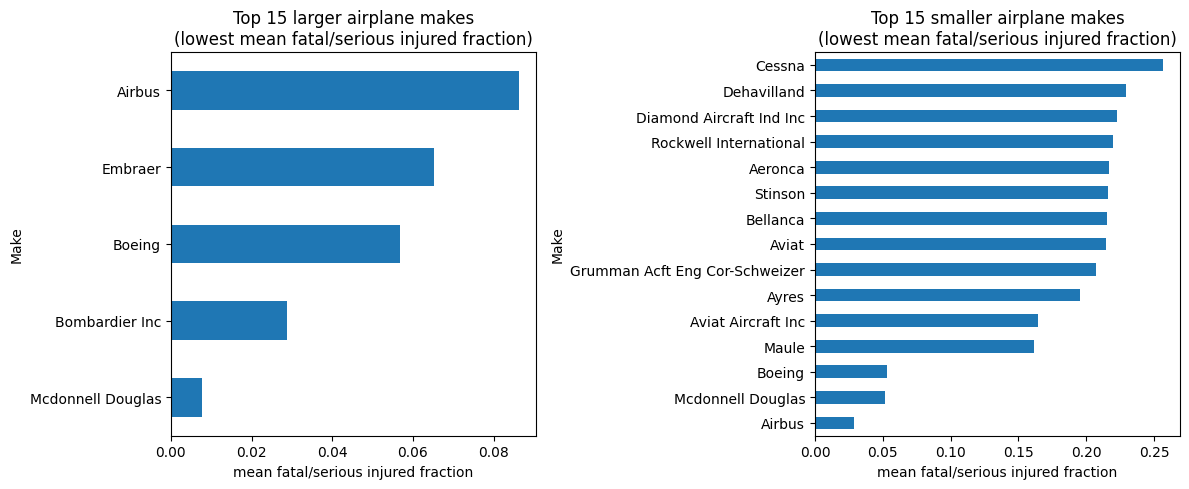

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
larger_airplane_15_lowest.plot.barh(ax=ax1, xlabel="mean fatal/serious injured fraction", title="Top 15 larger airplane makes\n(lowest mean fatal/serious injured fraction)")
smaller_airplane_15_lowest.plot.barh(ax=ax2, xlabel="mean fatal/serious injured fraction", title="Top 15 smaller airplane makes\n(lowest mean fatal/serious injured fraction)")
plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

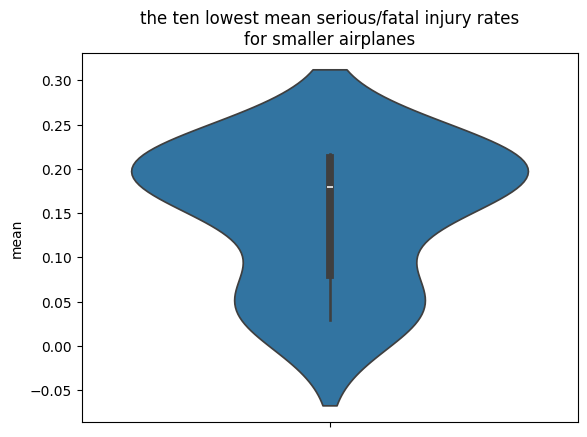

In [11]:
sns.violinplot(smaller_airplane_15_lowest[:10])
plt.title("the ten lowest mean serious/fatal injury rates\nfor smaller airplanes")
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

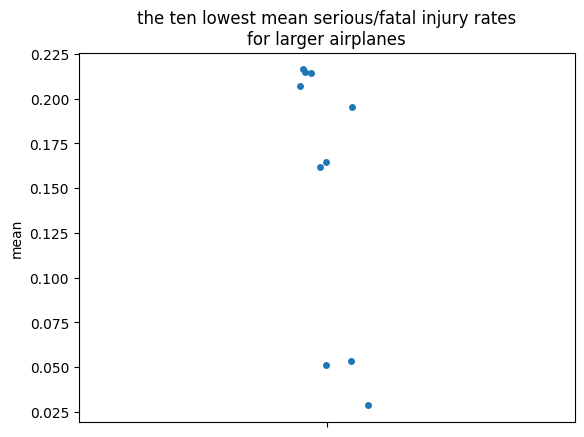

In [12]:
sns.stripplot(smaller_airplane_15_lowest[:10])
plt.title("the ten lowest mean serious/fatal injury rates\nfor larger airplanes")
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [13]:
result1 = cleaned_aviation_data.groupby(["Is.smaller.airplane", "Make"])["Is.aircraft.destroyed"].agg(["mean", "count"])
# ---------------------------------------------------
# Although I did not see that assignment instructions say do this, I felt it was needed to provided a proper analysis.
# I am choosing a sample size for each group to be about 30 as this tends to be the standard.
result1 = result1[result1["count"] >= 30]
#-----------------------------------------------------
larger_airplane_15_lowest_destroyed = result1.loc[False, "mean"].sort_values()[:15]
smaller_airplane_15_lowest_destroyed = result1.loc[True, "mean"].sort_values()[:15]
print(larger_airplane_15_lowest_destroyed)
print()
print(smaller_airplane_15_lowest_destroyed)

Make
Bombardier Inc       0.023256
Boeing               0.049360
Embraer              0.051282
Mcdonnell Douglas    0.075472
Airbus               0.076271
Name: mean, dtype: float64

Make
Luscombe                          0.014184
Grumman Acft Eng Cor-Schweizer    0.017241
Stinson                           0.023256
Airbus                            0.024000
Taylorcraft                       0.032258
Aeronca                           0.035000
Boeing                            0.036415
Ercoupe                           0.038462
American Champion Aircraft        0.038462
Aviat Aircraft Inc                0.039474
Maule                             0.041860
Dehavilland                       0.042553
Bellanca                          0.050228
Diamond Aircraft Ind Inc          0.054054
Mcdonnell Douglas                 0.072727
Name: mean, dtype: float64


In [14]:
print(larger_airplane_15_lowest_destroyed.describe())
print()
print(smaller_airplane_15_lowest_destroyed.describe())

count    5.000000
mean     0.055128
std      0.021936
min      0.023256
25%      0.049360
50%      0.051282
75%      0.075472
max      0.076271
Name: mean, dtype: float64

count    15.000000
mean      0.037345
std       0.014883
min       0.014184
25%       0.028129
50%       0.038462
75%       0.042207
max       0.072727
Name: mean, dtype: float64


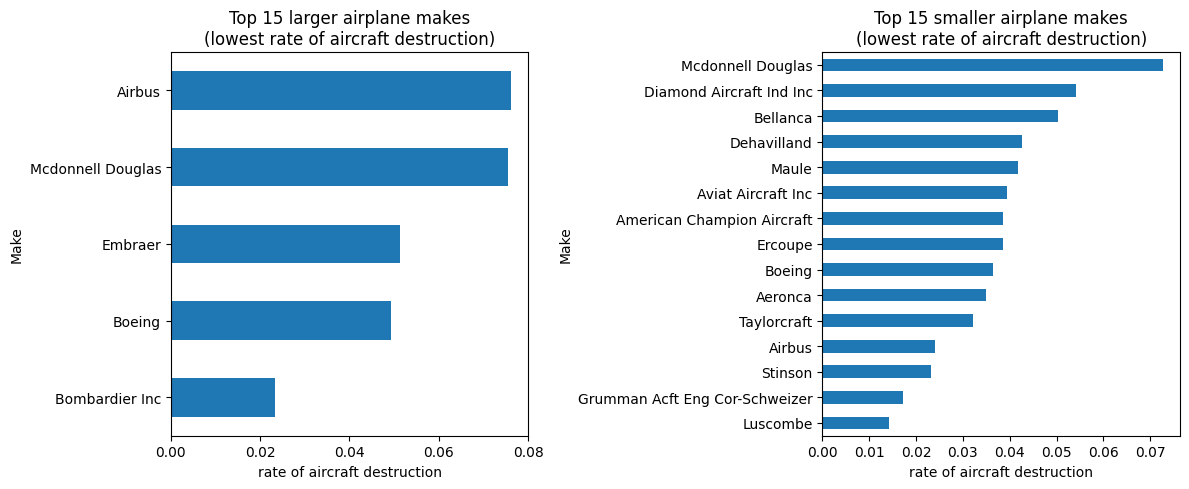

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
larger_airplane_15_lowest_destroyed.plot.barh(ax=ax1, xlabel="rate of aircraft destruction", title="Top 15 larger airplane makes\n(lowest rate of aircraft destruction)")
smaller_airplane_15_lowest_destroyed.plot.barh(ax=ax2, xlabel="rate of aircraft destruction", title="Top 15 smaller airplane makes\n(lowest rate of aircraft destruction)")
plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

For smaller airplanes, Airbus is the only airplane make in the top 5 lowest for the both the rate of aircraft destruction at about 0.02 and the mean fatal/serious injured fraction at about 0.03. I recommend Airbus as the make to use for smaller airplanes.

For larger airplanes, Bombardier Inc is the only airplane make in the top 2 for the lowest rate of aircraft destruction at about 0.02 and the second lowest mean fatal/serious injured fraction at about 0.03. I recommend Bombardier as the make to use for larger airplanes.

Note: My analysis was done with a sample size of at least 30 for each combination of values for Make and Is.smaller.airplane.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

In [16]:
num_examples_per_make_model_threshold = 10 # Since the instructions explicitly says use 10, I am using 10 here instead of 30.
grouped_result2 = cleaned_aviation_data.groupby(["Is.smaller.airplane", "Make.model"])["Likelihood.of.serious.or.fatal.injury"].agg(["mean", "count"])
relevant_grouped_result2 = grouped_result2[grouped_result2["count"] >= num_examples_per_make_model_threshold]
larger_airplane_15_lowest2 = relevant_grouped_result2.loc[False, "mean"].sort_values()[:15]
smaller_airplane_15_lowest2 = relevant_grouped_result2.loc[True, "mean"].sort_values()[:15]
relevant_grouped_result2.head(20)

mean  count
Is.smaller.airplane Make.model                                 
False               Airbus/a320                 0.126328     24
                    Airbus/a321                 0.200000     10
                    Airbus/a330                 0.146872     14
                    Boeing/737                  0.081223    163
                    Boeing/737 7h4              0.068121     14
                    Boeing/737-7h4              0.003242     12
                    Boeing/747                  0.023161     11
                    Boeing/757                  0.001473     18
                    Boeing/767                  0.046963     31
                    Boeing/777                  0.000821     33
                    Boeing/787                  0.003058     11
                    Bombardier Inc/cl-600-2b19  0.004431     14
                    Embraer/emb-145lr           0.010000     15
                    Embraer/emb145              0.008798     11
True                Aero Commander/100          0.291667     12
                    Aero Commander/s2r          0.235294     17
                    Aeronca/11ac                0.232143     28
                    Aeronca/15ac                0.090909     11
                    Aeronca/7ac                 0.258427     89
                    Aeronca/7bcm                0.321429     14

In [17]:
print(larger_airplane_15_lowest2)
print()
print(smaller_airplane_15_lowest2)

Make.model
Boeing/777                    0.000821
Boeing/757                    0.001473
Boeing/787                    0.003058
Boeing/737-7h4                0.003242
Bombardier Inc/cl-600-2b19    0.004431
Embraer/emb145                0.008798
Embraer/emb-145lr             0.010000
Boeing/747                    0.023161
Boeing/767                    0.046963
Boeing/737 7h4                0.068121
Boeing/737                    0.081223
Airbus/a320                   0.126328
Airbus/a330                   0.146872
Airbus/a321                   0.200000
Name: mean, dtype: float64

Make.model
Boeing/737-800                       0.000000
Boeing/777                           0.000000
Boeing/787                           0.000000
Maule/m-5-210c                       0.000000
Diamond Aircraft Ind Inc/da 20 c1    0.000000
Cessna/172sp                         0.000000
Airbus/a321                          0.000000
Embraer/erj190                       0.000000
Beech/1900d                         

**Larger planes**

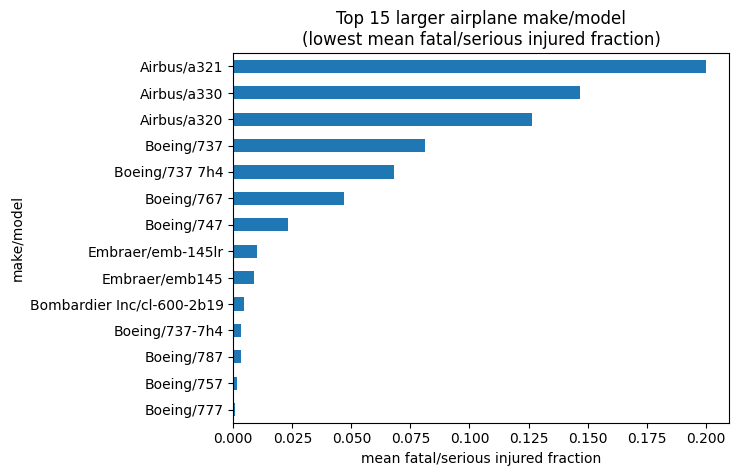

In [18]:
larger_airplane_15_lowest2.plot.barh(
  xlabel="mean fatal/serious injured fraction",
  ylabel="make/model",
  title="Top 15 larger airplane make/model\n(lowest mean fatal/serious injured fraction)")
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

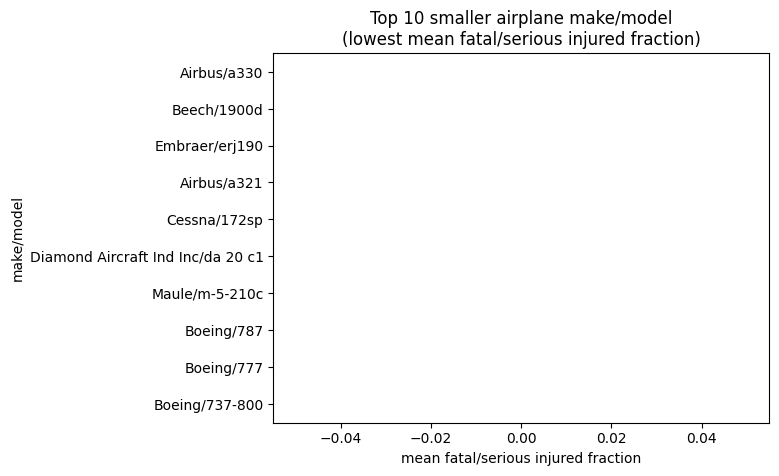

In [19]:
smaller_airplane_15_lowest2[:10].plot.barh(
  xlabel="mean fatal/serious injured fraction",
  ylabel="make/model",
  title="Top 10 smaller airplane make/model\n(lowest mean fatal/serious injured fraction)"
)
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

For larger airplanes:
  - None of the airplane types in the top 15 lowest mean fatal/serious injured fraction exceed 0.2.
  - More than half of the airplane types in the top 15 lowest mean fatal/serious injured fraction came from Boeing.
  - 80% of the airplane types in the top 5 lowest mean fatal/serious injured fraction came from Boeing.
  - I recommend the Boeing/777, Boeing/757, and Boeing/787 make/model because are the top three lowest for the mean fatal/serious fraction with about 0.001, 0.001, and 0.003, respectively. I rounded to the nearest thousandths.

For smaller airplanes
  - All the airplane types in top 10 lowest mean fatal/serious injured fraction had their values as 0, so there were no fatal/serious injuries for their accidents, and Boeing/777 and Boeing/787 are among these 10.
  - I recommend any of these 10 because they had no fatal/serious injuries.

If I had to recommend two specific make/models that can be used for larger and smaller airplanes, I would go with Boeing/777 and Boeing/787 for reasons listed above.

Note: The sample size is at least 10 (based on the assignment's instructions) for each combination of values for Make.model and Is.smaller.airplane.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

#### Exploring Weather Condition

##### For the mean fatal/serious injured fraction 

In [20]:
factor_to_try = "Weather.Condition"
num_samples_per_group = 30 # making sure that there are at least this number of samples so that there are enough samples when making comparisons between groups
grouped_result3 = cleaned_aviation_data.groupby(["Is.smaller.airplane", factor_to_try])["Likelihood.of.serious.or.fatal.injury"].agg(["mean", "count"])
relevant_grouped_result3 = grouped_result3[grouped_result3["count"] >= 30]
larger_airplane_15_lowest3 = relevant_grouped_result3.loc[False, "mean"].sort_values()[:15]
smaller_airplane_15_lowest3 = relevant_grouped_result3.loc[True, "mean"].sort_values()[:15]
relevant_grouped_result3

mean  count
Is.smaller.airplane Weather.Condition                 
False               IMC                0.111517     72
                    UNK                0.015332     63
                    VMC                0.058841    739
True                IMC                0.644062    833
                    UNK                0.458739    199
                    VMC                0.246737  15973

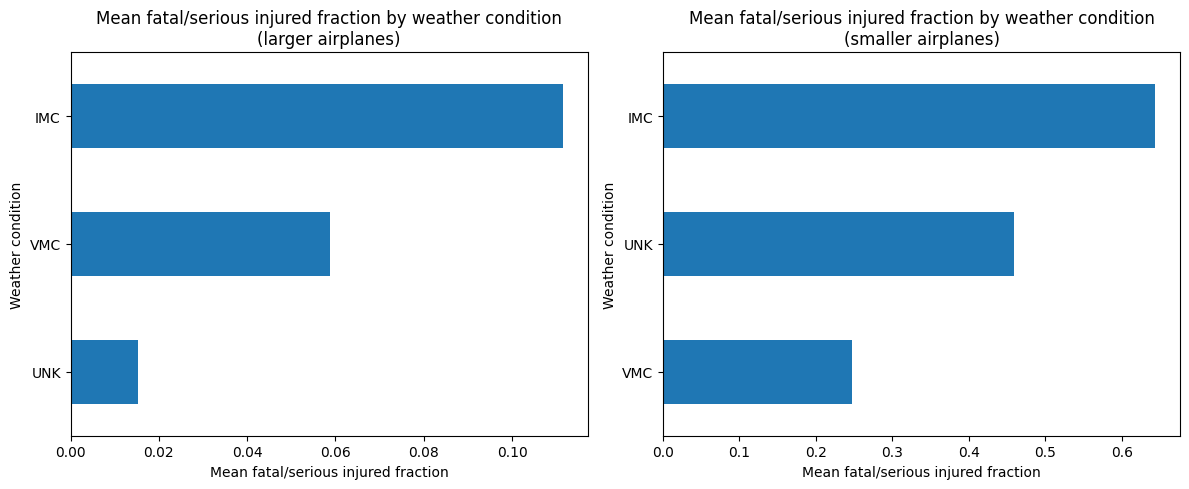

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
larger_airplane_15_lowest3.plot.barh(
  ax=ax1,
  xlabel="Mean fatal/serious injured fraction",
  ylabel="Weather condition",
  title="Mean fatal/serious injured fraction by weather condition\n(larger airplanes)"
)
smaller_airplane_15_lowest3.plot.barh(
  ax=ax2,
  xlabel="Mean fatal/serious injured fraction",
  ylabel="Weather condition",
  title="Mean fatal/serious injured fraction by weather condition\n(smaller airplanes)"
)
plt.tight_layout()
plt.show()

##### For the rate of aircraft destruction

In [22]:
factor_to_try = "Weather.Condition"
num_samples_per_group = 30 # making sure that there are at least this number of samples so that there are enough samples when making comparisons between groups
grouped_result4 = cleaned_aviation_data.groupby(["Is.smaller.airplane", factor_to_try])["Is.aircraft.destroyed"].agg(["mean", "count"])
relevant_grouped_result4 = grouped_result4[grouped_result4["count"] >= 30]
larger_airplane_15_lowest_destroyed2 = relevant_grouped_result4.loc[False, "mean"].sort_values()[:15]
smaller_airplane_15_lowest_destroyed2 = relevant_grouped_result4.loc[True, "mean"].sort_values()[:15]
relevant_grouped_result4

mean  count
Is.smaller.airplane Weather.Condition                 
False               IMC                0.083333     72
                    UNK                0.031746     63
                    VMC                0.055480    739
True                IMC                0.370948    833
                    UNK                0.336683    199
                    VMC                0.087773  15973

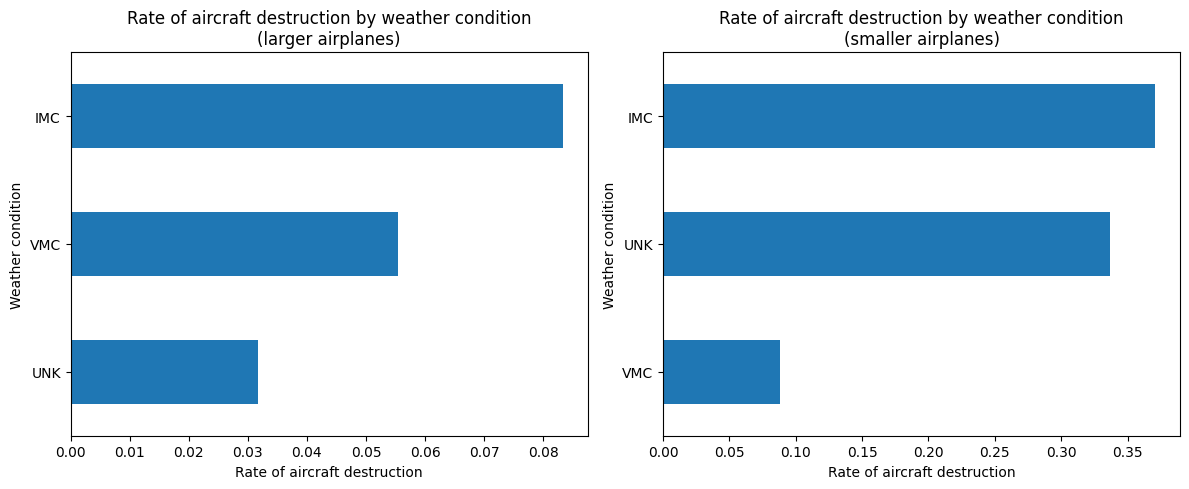

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
larger_airplane_15_lowest_destroyed2.plot.barh(
  ax=ax1,
  xlabel="Rate of aircraft destruction",
  ylabel="Weather condition",
  title="Rate of aircraft destruction by weather condition\n(larger airplanes)"
)
smaller_airplane_15_lowest_destroyed2.plot.barh(
  ax=ax2,
  xlabel="Rate of aircraft destruction",
  ylabel="Weather condition",
  title="Rate of aircraft destruction by weather condition\n(smaller airplanes)"
)
plt.tight_layout()
plt.show()

#### Exploring Number of Engines

##### For the mean fatal/serious injured fraction

In [24]:
factor_to_try = "Number.of.Engines"
num_samples_per_group = 30 # making sure that there are at least this number of samples so that there are enough samples when making comparisons between groups
grouped_result3 = cleaned_aviation_data.groupby(["Is.smaller.airplane", factor_to_try])["Likelihood.of.serious.or.fatal.injury"].agg(["mean", "count"])
relevant_grouped_result3 = grouped_result3[grouped_result3["count"] >= 30]
larger_airplane_15_lowest3 = relevant_grouped_result3.loc[False, "mean"].sort_values()[:15]
smaller_airplane_15_lowest3 = relevant_grouped_result3.loc[True, "mean"].sort_values()[:15]
relevant_grouped_result3

mean  count
Is.smaller.airplane Number.of.Engines                 
False               1                  0.097054    302
                    2                  0.039119    542
True                1                  0.264460  15009
                    2                  0.307113   1928
                    4                  0.130869     44

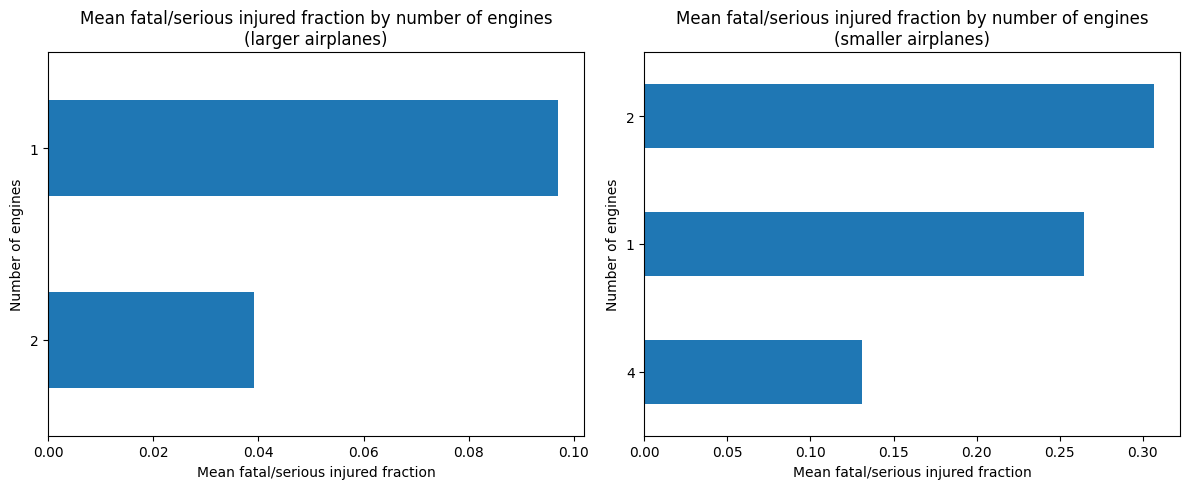

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
larger_airplane_15_lowest3.plot.barh(
  ax=ax1,
  xlabel="Mean fatal/serious injured fraction",
  ylabel="Number of engines",
  title="Mean fatal/serious injured fraction by number of engines\n(larger airplanes)"
)
smaller_airplane_15_lowest3.plot.barh(
  ax=ax2,
  xlabel="Mean fatal/serious injured fraction",
  ylabel="Number of engines",
  title="Mean fatal/serious injured fraction by number of engines\n(smaller airplanes)"
)
plt.tight_layout()
plt.show()

##### For the rate of airplane destruction

In [26]:
factor_to_try = "Number.of.Engines"
num_samples_per_group = 30 # making sure that there are at least this number of samples so that there are enough samples when making comparisons between groups
grouped_result4 = cleaned_aviation_data.groupby(["Is.smaller.airplane", factor_to_try])["Is.aircraft.destroyed"].agg(["mean", "count"])
relevant_grouped_result4 = grouped_result4[grouped_result4["count"] >= 30]
larger_airplane_15_lowest_destroyed2 = relevant_grouped_result4.loc[False, "mean"].sort_values()[:15]
smaller_airplane_15_lowest_destroyed2 = relevant_grouped_result4.loc[True, "mean"].sort_values()[:15]
relevant_grouped_result4

mean  count
Is.smaller.airplane Number.of.Engines                 
False               1                  0.102649    302
                    2                  0.031365    542
True                1                  0.096809  15009
                    2                  0.164938   1928
                    4                  0.113636     44

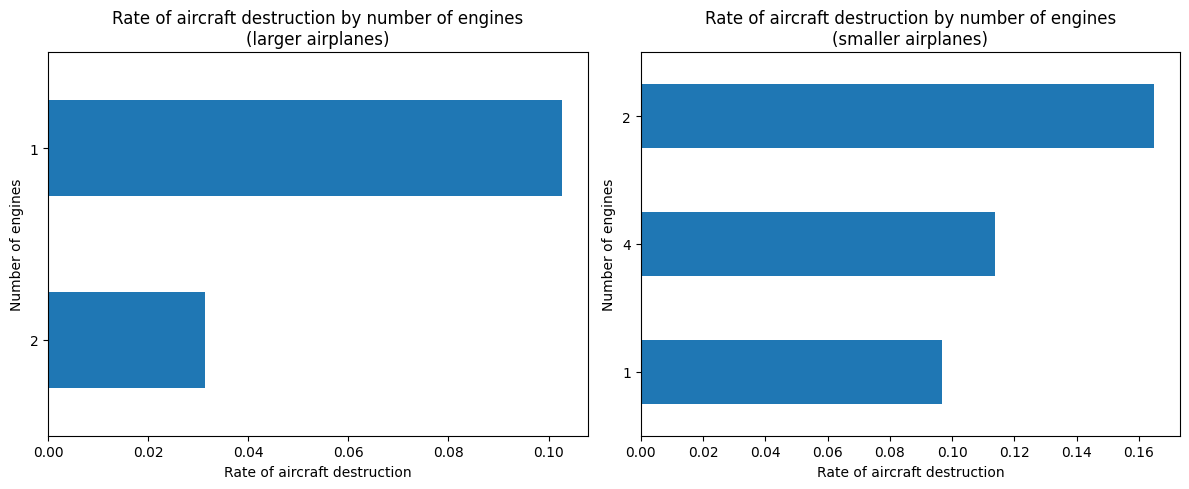

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
larger_airplane_15_lowest_destroyed2.plot.barh(
  ax=ax1,
  xlabel="Rate of aircraft destruction",
  ylabel="Number of engines",
  title="Rate of aircraft destruction by number of engines\n(larger airplanes)"
)
smaller_airplane_15_lowest_destroyed2.plot.barh(
  ax=ax2,
  xlabel="Rate of aircraft destruction",
  ylabel="Number of engines",
  title="Rate of aircraft destruction by number of engines\n(smaller airplanes)"
)
plt.tight_layout()
plt.show()

#### Discussion/Recommendations

For larger airplane makes and weather conditions:
  - IMC has the highest rate of aircraft destruction (at about 0.08) and highest mean fatal/serious injured fraction (at about 0.11) among the weather conditions.
  - UNK has the lowest rate of aircraft destruction (at about 0.03) and lowest mean fatal/serious injured fraction (at about 0.02) among the weather conditions with at least 30 samples for larger airplanes
    - Note: Since UNK represents unknown weather conditions, I will focus on VMC, which had the next lowest rate of aircraft destruction (at about 0.06) and mean fatal/serious injured fraction (at about 0.06).

For smaller airplane makes and weather conditions:
  - IMC has the highest rate of aircraft destruction (at about 0.37) and highest mean fatal/serious injured fraction (at about 0.64) among the weather conditions.
  - VMC has the lowest rate of aircraft destruction (at about 0.09) and lowest mean fatal/serious injured fraction (at about 0.25) among the weather conditions with at least 30 samples for smaller airplanes.

For larger airplane makes and number of engines:
  - One engines has the highest rate of aircraft destruction (at about 0.10) and highest mean fatal/serious injured fraction (at about 0.10) among the number of engines with at least 30 samples for larger airplanes.
  - Two engines has the lowest rate of aircraft destruction (at about 0.03) and lowest mean fatal/serious injured fraction (at about 0.04) among the number of engines with at least 30 samples for larger airplanes.

For smaller airplane makes and number of engines:
  - Two engines has the highest rate of aircraft destruction (at about 0.16) and highest mean fatal/serious injured fraction (at about 0.30) among the number of engines with at least 30 samples for smaller airplanes.
  - One engine has the lowest rate of aircraft destruction (at about 0.10) and is in the middle for the mean fatal/serious injured fraction (at about 0.26) among the number of engines with at least 30 samples for smaller airplanes.
  - Four engines is in the middle for the rate of aircraft destruction (at about 0.11) and has the lowest mean fatal/serious injured fraction (at about 0.13) among the number of engines with at least 30 samples for smaller airplanes.

Recommendation for airplanes based on weather conditions: For smaller airplanes, choose VMC over IMC because VMC has less than a fourth of the rate of aircraft destruction and has less than half the mean fatal/serious injured fraction compared to IMC. For larger airplanes, choose VMC over IMC because VMC has about three fourths of the rate of aircraft destruction and has almost half of the mean fatal/serious injured fraction compared to IMC. For both smaller and larger airplanes go with VMC and avoid IMC as much as possible.

Recommendation for airplanes based on number of engines: For smaller airplanes, choose four engines over two engines because four engines has a lower rate of aircraft destruction and mean fatal/serious injured fraction. The reason to choose four engines over one engine is because four engines reduces the mean fatal/serious injured fraction by about 51% compared to one engine while only increasing the rate of aircraft destruction by about 17% compared to one engine. However, if the rate of aircraft destruction is so much more important compared to the mean fatal/serious injured fraction, then it would be better to go with one engine. For larger airplanes, choose two engines over one engine because two engines has less than a third of the rate of aircraft destruction and and less than half of the mean fatal/serious injured fraction compared to one engine.

Note: My analysis and recommendations are based on a sample size of at least 30 for each combination of Is.smaller.airplane and Weather.Condition and each combination of values for Is.smaller.airplane and Number.of.Engines.